# PCA as a Baseline for Asteroid Taxonomic Recovery

This notebook evaluates how effectively PCA preserves taxonomic structure in two asteroid spectral classifications:

- **Bus–Binzel VIS**
- **Bus-DeMeo VIS–NIR**

Only spectral reflectance variables are used. PCA is fitted independently for each dataset. KMeans is used as a fixed unsupervised probe of the PCA representation. Global agreement is quantified with **ARI**, while class-level recoverability is quantified with **F1-score**.

Recovery bands:

- **0.60 ≤ F1 < 0.70**: limited recovery
- **0.70 ≤ F1 < 0.80**: moderate recovery
- **0.80 ≤ F1 < 0.90**: strong recovery
- **F1 ≥ 0.90**: very strong recovery
- **F1 < 0.60**: weak/unresolved

PCA dimensionalities from **PC1–PC2 through PC1–PC50** are evaluated for both datasets, or up to the maximum available number of components if fewer than 50 exist.

In [43]:
from pathlib import Path
import re
import warnings
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, f1_score
from scipy.optimize import linear_sum_assignment
from scipy.stats import mannwhitneyu, spearmanr
warnings.filterwarnings('ignore')

mpl.rcParams.update({'font.family':'serif','font.serif':['Times New Roman'],'font.size':17,'axes.titlesize':18,'axes.labelsize':18,'xtick.labelsize':17,'ytick.labelsize':17,'legend.fontsize':18,'figure.titlesize':19,'figure.dpi':120,'savefig.dpi':300,'pdf.fonttype':42,'ps.fonttype':42,'axes.unicode_minus':False})

RANDOM_STATE=42
MAX_PCS=50
N_INIT=50
RESULTS=Path.cwd()/'PCA_Chapter_Analysis_Results'
VISUALS=RESULTS/'visuals'
TABLES=RESULTS/'tables'
VISUALS.mkdir(parents=True,exist_ok=True)
TABLES.mkdir(parents=True,exist_ok=True)
print('Results folder:',RESULTS.resolve())

Results folder: C:\Users\anaoj\Desktop\Citedi\Avances\Capítulo de Libro\PCA_Chapter_Analysis_Results


## 1. Read datasets

In [45]:
import tkinter as tk
from tkinter import filedialog

ROOT=Path('.')
DATA=ROOT/'data'

bus_default=DATA/'Bus_Binzel_original.csv'
demeo_default=DATA/'03_asteroids.csv'

if bus_default.exists() and demeo_default.exists():
    bus_path=bus_default
    demeo_path=demeo_default
else:
    root=tk.Tk()
    root.withdraw()
    root.attributes('-topmost',True)
    bus_path=Path(filedialog.askopenfilename(title='Select Bus_Binzel_original.csv',filetypes=[('CSV files','*.csv')]))
    demeo_path=Path(filedialog.askopenfilename(title='Select 03_asteroids.csv',filetypes=[('CSV files','*.csv')]))
    root.destroy()

if not bus_path.exists() or not demeo_path.exists():
    raise FileNotFoundError('Both CSV files are required')

bus_raw=pd.read_csv(bus_path)
demeo_raw=pd.read_csv(demeo_path)

print('Bus-Binzel:',bus_raw.shape,bus_path)
print('DeMeo:',demeo_raw.shape,demeo_path)

Bus-Binzel: (1335, 202) C:\Users\anaoj\Desktop\Citedi\Avances\Capítulo de Libro\PDS_Asteroids_Output\Bus_Binzel_original.csv
DeMeo: (2596, 58) C:\Users\anaoj\Desktop\Citedi\Avances\Tesis\Code\Códigos\03_asteroids.csv


## 2. Dataset overview and class distributions

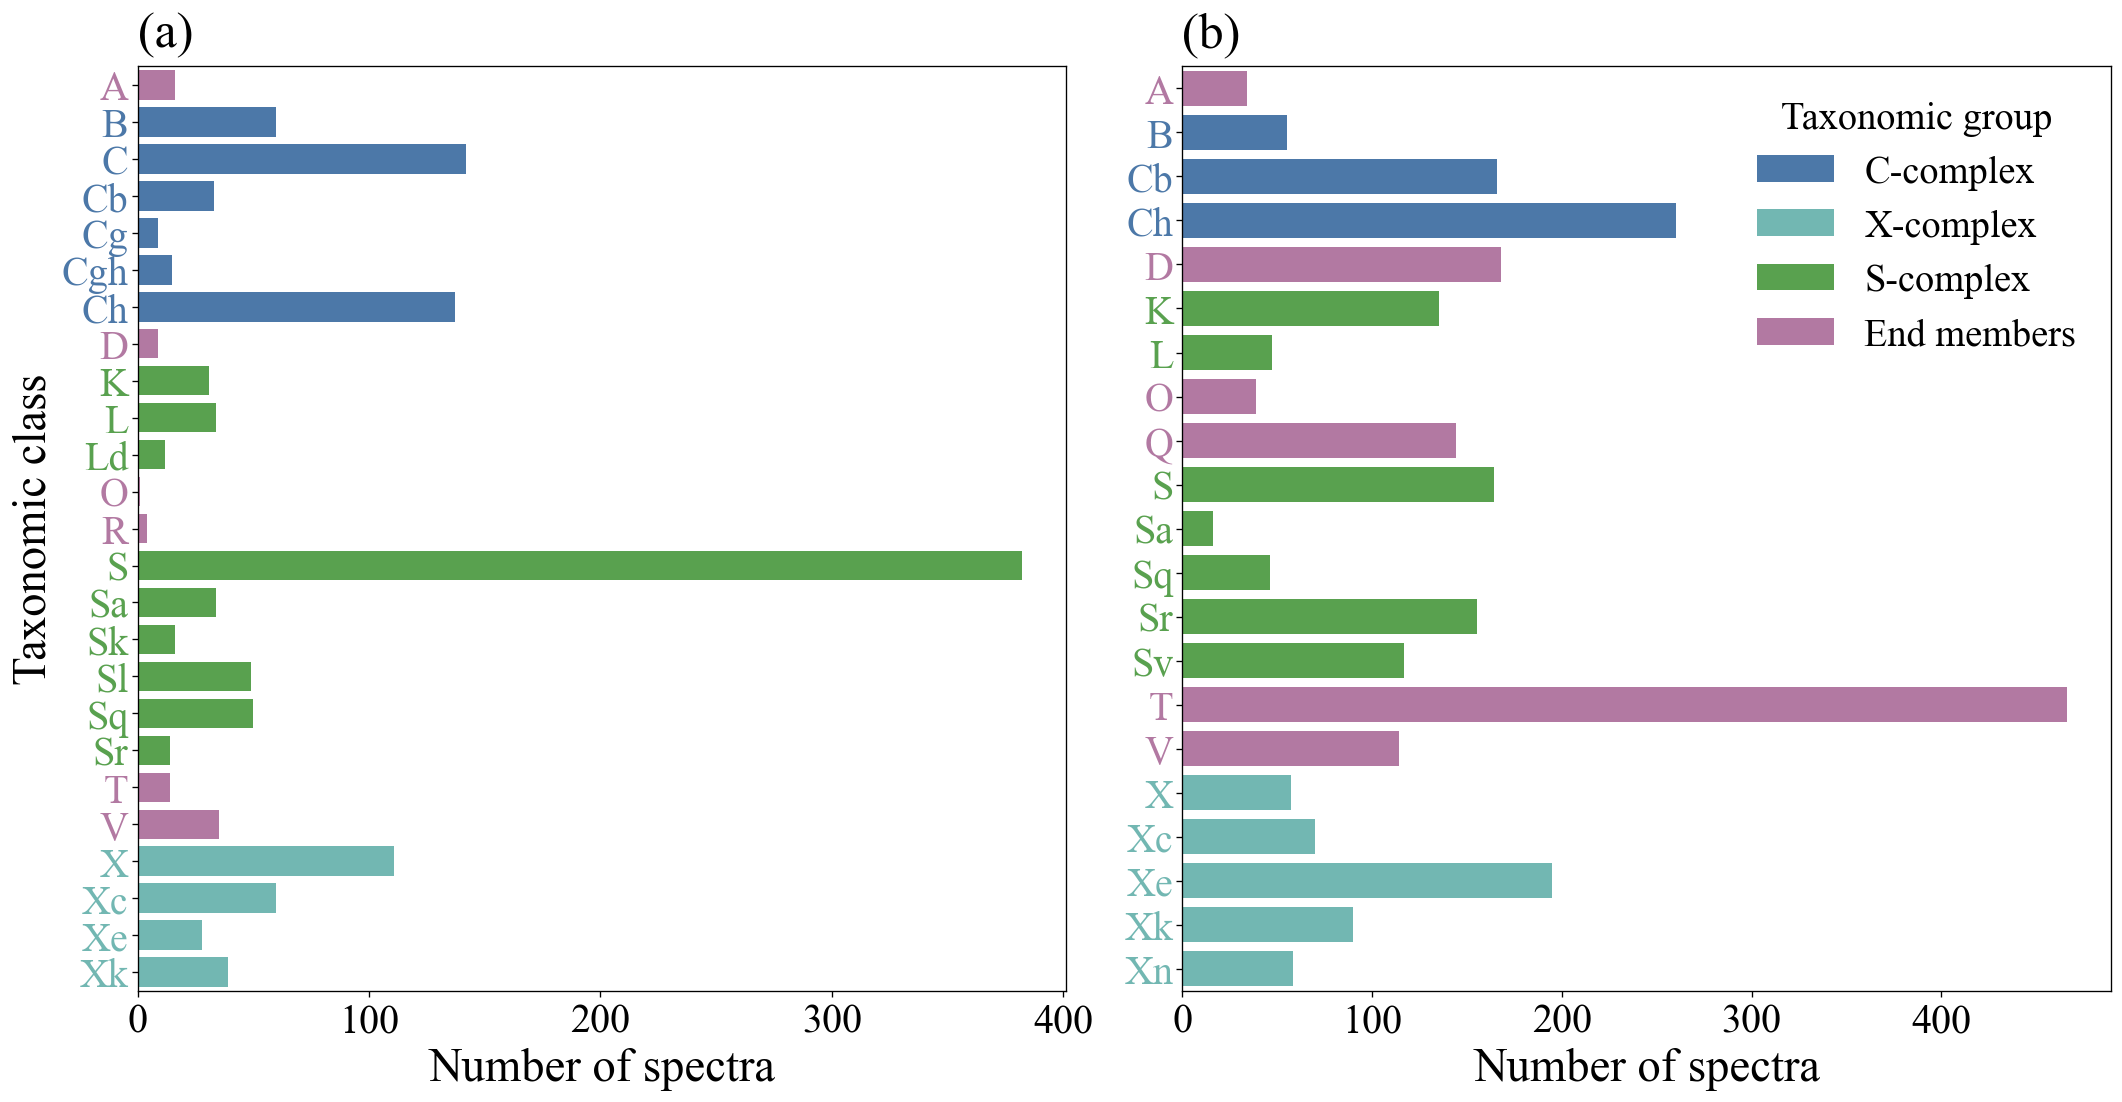

,dataset,samples,classes
0,Bus-Binzel VIS,1335,25
1,DeMeo VIS-NIR,2596,21


,class,samples,dataset
0,A,16,Bus-Binzel VIS
1,B,60,Bus-Binzel VIS
2,C,142,Bus-Binzel VIS
3,Cb,33,Bus-Binzel VIS
4,Cg,9,Bus-Binzel VIS
5,Cgh,15,Bus-Binzel VIS
6,Ch,137,Bus-Binzel VIS
7,D,9,Bus-Binzel VIS
8,K,31,Bus-Binzel VIS
9,L,34,Bus-Binzel VIS


In [47]:
from matplotlib.patches import Patch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

bus_counts=bus_raw['class_bus'].astype(str).value_counts().sort_index()
demeo_counts=demeo_raw['class_demeo'].astype(str).value_counts().sort_index()

dataset_overview=pd.DataFrame([
    {'dataset':'Bus-Binzel VIS','samples':len(bus_raw),'classes':bus_counts.size},
    {'dataset':'DeMeo VIS-NIR','samples':len(demeo_raw),'classes':demeo_counts.size}
])
dataset_overview.to_csv(TABLES/'dataset_overview_raw.csv',index=False)

bus_cc=bus_counts.rename_axis('class').reset_index(name='samples').assign(dataset='Bus-Binzel VIS')
demeo_cc=demeo_counts.rename_axis('class').reset_index(name='samples').assign(dataset='DeMeo VIS-NIR')
class_counts=pd.concat([bus_cc,demeo_cc],ignore_index=True)
class_counts.to_csv(TABLES/'class_counts_raw.csv',index=False)

bus_groups={
    'B':'C-complex','C':'C-complex','Cb':'C-complex','Cg':'C-complex','Cgh':'C-complex','Ch':'C-complex',
    'X':'X-complex','Xc':'X-complex','Xe':'X-complex','Xk':'X-complex',
    'K':'S-complex','L':'S-complex','Ld':'S-complex','S':'S-complex','Sa':'S-complex','Sk':'S-complex','Sl':'S-complex','Sq':'S-complex','Sr':'S-complex',
    'A':'End members','D':'End members','O':'End members','R':'End members','T':'End members','V':'End members'
}
demeo_groups={
    'B':'C-complex','Cb':'C-complex','Ch':'C-complex',
    'X':'X-complex','Xc':'X-complex','Xe':'X-complex','Xk':'X-complex','Xn':'X-complex',
    'K':'S-complex','L':'S-complex','S':'S-complex','Sa':'S-complex','Sq':'S-complex','Sr':'S-complex','Sv':'S-complex',
    'A':'End members','D':'End members','O':'End members','Q':'End members','T':'End members','V':'End members'
}

palette={
    'C-complex':'#4C78A8',
    'X-complex':'#72B7B2',
    'S-complex':'#59A14F',
    'End members':'#B279A2',
    'Other':'#9D9D9D'
}

bus_plot=bus_counts.rename_axis('class').reset_index(name='samples')
bus_plot['group']=bus_plot['class'].map(bus_groups).fillna('Other')
bus_plot['color']=bus_plot['group'].map(palette)

demeo_plot=demeo_counts.rename_axis('class').reset_index(name='samples')
demeo_plot['group']=demeo_plot['class'].map(demeo_groups).fillna('Other')
demeo_plot['color']=demeo_plot['group'].map(palette)

fig,axs=plt.subplots(1,2,figsize=(18,10))

y0=np.arange(len(bus_plot))
axs[0].barh(y0,bus_plot['samples'],color=bus_plot['color'])
axs[0].set_yticks(y0,bus_plot['class'])
axs[0].set_xlabel('Number of spectra',fontsize=28)
axs[0].set_ylabel('Taxonomic class',fontsize=28)
axs[0].tick_params(axis='x',labelsize=24)
axs[0].tick_params(axis='y',labelsize=24, pad=2)
axs[0].invert_yaxis()
axs[0].set_ylim(len(bus_plot)-0.5,-0.5)
axs[0].text(0.0,1.01,'(a)',transform=axs[0].transAxes,fontsize=30,va='bottom',ha='left')
for tick,grp in zip(axs[0].get_yticklabels(),bus_plot['group']):
    tick.set_color(palette[grp])

y1=np.arange(len(demeo_plot))
axs[1].barh(y1,demeo_plot['samples'],color=demeo_plot['color'])
axs[1].set_yticks(y1,demeo_plot['class'])
axs[1].set_xlabel('Number of spectra',fontsize=28)
axs[1].tick_params(axis='x',labelsize=24)
axs[1].tick_params(axis='y',labelsize=24, pad=2)
axs[1].invert_yaxis()
axs[1].set_ylim(len(demeo_plot)-0.5,-0.5)
axs[1].text(0.0,1.01,'(b)',transform=axs[1].transAxes,fontsize=30,va='bottom',ha='left')
for tick,grp in zip(axs[1].get_yticklabels(),demeo_plot['group']):
    tick.set_color(palette[grp])

handles=[Patch(facecolor=palette[g],label=g) for g in ['C-complex','X-complex','S-complex','End members']]
axs[1].legend(handles=handles,loc='upper right',frameon=False,fontsize=23,title='Taxonomic group',title_fontsize=23)
fig.tight_layout(rect=[0,0,1,0.95])
fig.savefig(VISUALS/'01_class_distribution.png',bbox_inches='tight',dpi=300)
fig.savefig(VISUALS/'01_class_distribution.pdf',bbox_inches='tight')
plt.show()

display(dataset_overview)
display(class_counts) 

## 3. Spectral-variable detection and preprocessing audit

In [49]:
bus_spec=sorted([c for c in bus_raw.columns if re.fullmatch(r'R_\d+(?:\.\d+)?',str(c)) and 0.435<=float(str(c)[2:])<=0.925],key=lambda c:float(str(c)[2:]))
demeo_spec=sorted([c for c in demeo_raw.columns if re.fullmatch(r'\d+(?:\.\d+)?',str(c)) and 0.45<=float(c)<=2.45],key=float)

bus0=bus_raw.copy()
bus0[bus_spec]=bus0[bus_spec].apply(pd.to_numeric,errors='coerce')
bus_missing_initial=int(bus0[bus_spec].isna().sum().sum())
bus_row_missing=bus0[bus_spec].isna().mean(axis=1)
bus_keep_missing=bus_row_missing<=0.15
bus_norm_col=min(bus_spec,key=lambda c:abs(float(c[2:])-0.55))
bus_keep_norm=bus0[bus_norm_col].notna() & np.isfinite(bus0[bus_norm_col]) & (bus0[bus_norm_col]!=0)
bus_keep=bus_keep_missing & bus_keep_norm
keep_cols=[c for c in ['asteroid_number','observation_id','class_bus'] if c in bus0.columns]
bus_removed=bus0.loc[~bus_keep,keep_cols].copy()
bus_removed['missing_fraction']=bus_row_missing.loc[~bus_keep].values
bus_removed['failed_missing_rule']=(~bus_keep_missing.loc[~bus_keep]).values
bus_removed['failed_055_rule']=(~bus_keep_norm.loc[~bus_keep]).values

bus1=bus0.loc[bus_keep].copy()
before_interp=int(bus1[bus_spec].isna().sum().sum())
bus_interp=bus1[bus_spec].interpolate(axis=1,limit_area='inside')
after_interp=int(bus_interp.isna().sum().sum())
bus_remaining_by_channel=bus_interp.isna().sum()
bus_removed_channels=bus_remaining_by_channel[bus_remaining_by_channel>0].index.tolist()
bus_final_spec=[c for c in bus_spec if c not in bus_removed_channels]
bus1.loc[:,bus_spec]=bus_interp
bus1=bus1.dropna(subset=bus_final_spec).copy()
X_bus=bus1[bus_final_spec].to_numpy(float)
norm_idx=bus_final_spec.index(bus_norm_col)
X_bus=X_bus/X_bus[:,[norm_idx]]
y_bus=bus1['class_bus'].astype(str).to_numpy()

demeo0=demeo_raw.copy()
demeo0[demeo_spec]=demeo0[demeo_spec].apply(pd.to_numeric,errors='coerce')
demeo_missing_initial=int(demeo0[demeo_spec].isna().sum().sum())
if demeo_missing_initial>0:
    raise ValueError(f'DeMeo spectral matrix contains {demeo_missing_initial} missing values; inspect before PCA')
demeo_norm_col=min(demeo_spec,key=lambda c:abs(float(c)-0.55))
demeo_keep=demeo0[demeo_norm_col].notna() & np.isfinite(demeo0[demeo_norm_col]) & (demeo0[demeo_norm_col]!=0)
demeo1=demeo0.loc[demeo_keep].copy()
X_demeo=demeo1[demeo_spec].to_numpy(float)
demeo_norm_idx=demeo_spec.index(demeo_norm_col)
X_demeo=X_demeo/X_demeo[:,[demeo_norm_idx]]
y_demeo=demeo1['class_demeo'].astype(str).to_numpy()

bus_channel_report=pd.DataFrame({
    'channel':bus_spec,
    'wavelength_um':[float(c[2:]) for c in bus_spec],
    'missing_initial':[int(bus0[c].isna().sum()) for c in bus_spec],
    'missing_after_interpolation':[int(bus_interp[c].isna().sum()) for c in bus_spec],
    'removed_channel':[c in bus_removed_channels for c in bus_spec]
})
bus_removed_channel_table=pd.DataFrame({'channel':bus_removed_channels,'wavelength_um':[float(c[2:]) for c in bus_removed_channels]})

quality_summary=pd.DataFrame([
    {'dataset':'Bus-Binzel VIS','raw_samples':len(bus0),'final_samples':len(bus1),'raw_channels':len(bus_spec),'final_channels':len(bus_final_spec),'missing_initial':bus_missing_initial,'missing_before_interpolation_after_row_filter':before_interp,'missing_after_interior_interpolation':after_interp,'removed_spectra':int((~bus_keep).sum()),'removed_channels':len(bus_removed_channels)},
    {'dataset':'DeMeo VIS-NIR','raw_samples':len(demeo0),'final_samples':len(demeo1),'raw_channels':len(demeo_spec),'final_channels':len(demeo_spec),'missing_initial':demeo_missing_initial,'missing_before_interpolation_after_row_filter':0,'missing_after_interior_interpolation':0,'removed_spectra':int((~demeo_keep).sum()),'removed_channels':0}
])

bus_removed.to_csv(TABLES/'bus_removed_spectra.csv',index=False)
bus_channel_report.to_csv(TABLES/'bus_channel_missing_report.csv',index=False)
bus_removed_channel_table.to_csv(TABLES/'bus_removed_channels.csv',index=False)
quality_summary.to_csv(TABLES/'preprocessing_quality_summary.csv',index=False)

display(quality_summary)
display(bus_removed_channel_table)

,dataset,raw_samples,final_samples,raw_channels,final_channels,missing_initial,missing_before_interpolation_after_row_filter,missing_after_interior_interpolation,removed_spectra,removed_channels
0,Bus-Binzel VIS,1335,1312,197,185,11271,10743,416,23,12
1,DeMeo VIS-NIR,2596,2596,53,53,0,0,0,0,0


,channel,wavelength_um
0,R_0.4350,0.4350
1,R_0.4375,0.4375
2,R_0.4400,0.4400
3,R_0.4425,0.4425
4,R_0.4450,0.4450
5,R_0.4475,0.4475
6,R_0.4500,0.4500
7,R_0.4525,0.4525
8,R_0.9175,0.9175
9,R_0.9200,0.9200


## 4. PCA models and explained variance

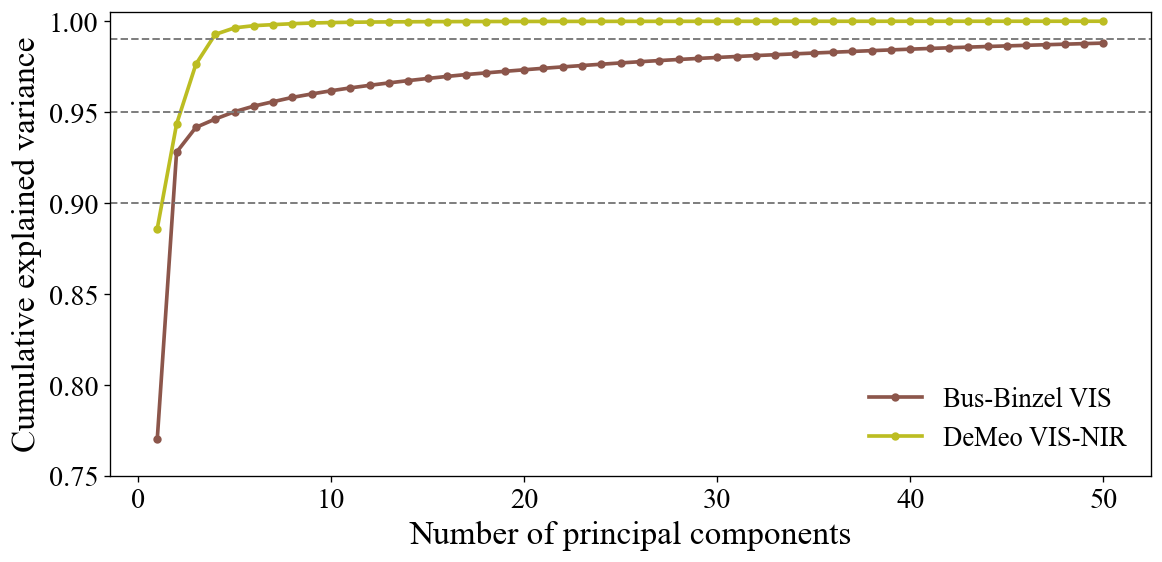

,dataset,PCs_90,PCs_95,PCs_99
0,Bus-Binzel VIS,2,5,NaN
1,DeMeo VIS-NIR,2,3,4.0


In [141]:
bus_ncomp=min(MAX_PCS,X_bus.shape[0]-1,X_bus.shape[1])
demeo_ncomp=min(MAX_PCS,X_demeo.shape[0]-1,X_demeo.shape[1])

pca_bus=PCA(n_components=bus_ncomp,svd_solver='full')
pca_demeo=PCA(n_components=demeo_ncomp,svd_solver='full')
Z_bus=pca_bus.fit_transform(X_bus)
Z_demeo=pca_demeo.fit_transform(X_demeo)

def variance_table(pca,name):
    evr=pca.explained_variance_ratio_
    return pd.DataFrame({'dataset':name,'PC':np.arange(1,len(evr)+1),'explained_variance':evr,'cumulative_variance':np.cumsum(evr)})

var_bus=variance_table(pca_bus,'Bus-Binzel VIS')
var_demeo=variance_table(pca_demeo,'DeMeo VIS-NIR')
variance_all=pd.concat([var_bus,var_demeo],ignore_index=True)
variance_all.to_csv(TABLES/'pca_explained_variance.csv',index=False)

def pcs_for(v,t):
    x=np.where(v['cumulative_variance'].to_numpy()>=t)[0]
    return int(x[0]+1) if len(x) else np.nan

variance_summary=pd.DataFrame([
    {'dataset':'Bus-Binzel VIS','PCs_90':pcs_for(var_bus,0.90),'PCs_95':pcs_for(var_bus,0.95),'PCs_99':pcs_for(var_bus,0.99)},
    {'dataset':'DeMeo VIS-NIR','PCs_90':pcs_for(var_demeo,0.90),'PCs_95':pcs_for(var_demeo,0.95),'PCs_99':pcs_for(var_demeo,0.99)}
])
variance_summary.to_csv(TABLES/'pca_variance_thresholds.csv',index=False)

fig,ax=plt.subplots(figsize=(10,5))
ax.plot(var_bus['PC'],var_bus['cumulative_variance'],marker='o',markersize=4,linewidth=2.2,color='#8C564B',label='Bus-Binzel VIS')
ax.plot(var_demeo['PC'],var_demeo['cumulative_variance'],marker='o',markersize=4,linewidth=2.2,color='#BCBD22',label='DeMeo VIS-NIR')

for t in [0.90,0.95,0.99]:
    ax.axhline(t,linestyle='--',linewidth=1.2,color='gray')

ax.set_xlabel('Number of principal components',fontsize=20)
ax.set_ylabel('Cumulative explained variance',fontsize=20)
ax.set_ylim(0.75,1.005)
ax.tick_params(axis='both',labelsize=17)
ax.legend(fontsize=16,frameon=False)

fig.tight_layout()
fig.savefig(VISUALS/'02_cumulative_explained_variance.png',bbox_inches='tight',dpi=300)
fig.savefig(VISUALS/'02_cumulative_explained_variance.pdf',bbox_inches='tight')
plt.show()

display(variance_summary)

## 5. PCA taxonomic-recovery scan

For every dimensionality from 2 to 50 PCs, KMeans is fitted using the number of taxonomic classes present in the corresponding dataset. Cluster labels are optimally matched to taxonomic labels using the Hungarian assignment. ARI evaluates the global partition, and F1 evaluates each individual class.

All classes remain in every dimensionality. This keeps the population fixed across PCs and makes ARI and F1 curves directly comparable.

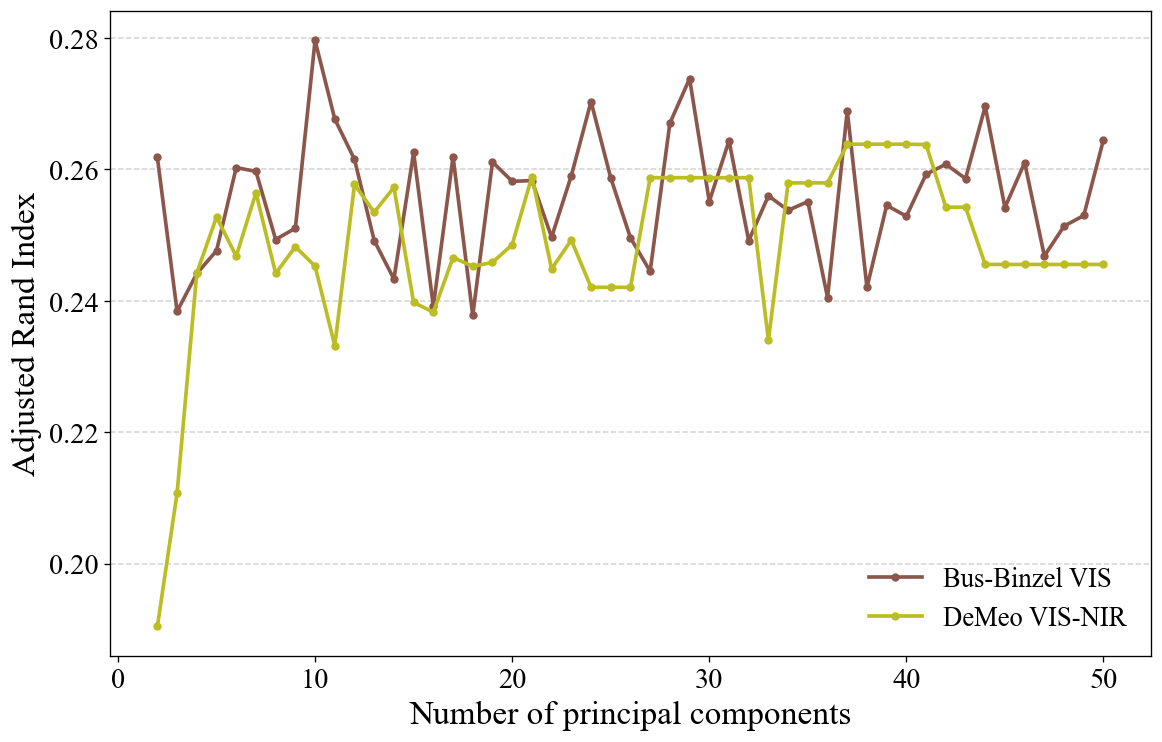

In [73]:
fig,ax=plt.subplots(figsize=(10,6.5))

for name,g in ari_all.groupby('dataset'):
    if name=='Bus-Binzel VIS':
        ax.plot(g['n_pcs'],g['ARI'],marker='o',markersize=4,linewidth=2.2,color='#8C564B',label='Bus-Binzel VIS')
    else:
        ax.plot(g['n_pcs'],g['ARI'],marker='o',markersize=4,linewidth=2.2,color='#BCBD22',label='DeMeo VIS-NIR')

ax.set_xlabel('Number of principal components',fontsize=20)
ax.set_ylabel('Adjusted Rand Index',fontsize=20)
ax.tick_params(axis='both',labelsize=17)

ax.grid(axis='y',linestyle='--',linewidth=0.9,alpha=0.35,color='gray')
ax.set_axisbelow(True)

ax.legend(fontsize=16,frameon=False)

fig.tight_layout()
fig.savefig(VISUALS/'03_ARI_vs_PCs.png',bbox_inches='tight',dpi=300)
fig.savefig(VISUALS/'03_ARI_vs_PCs.pdf',bbox_inches='tight')
plt.show()

## 6. Class-level recovery bands, best F1, and first threshold crossing

In [75]:
THRESHOLDS=[0.60,0.70,0.80,0.90]

def summarize_classes(metrics,counts,dataset_name):
    idx=metrics.groupby('class')['F1'].idxmax()
    best=metrics.loc[idx,['class','n_pcs','F1']].rename(columns={'n_pcs':'best_PC','F1':'max_F1'}).copy()
    best['samples']=best['class'].map(counts)
    def band(x):
        if x<0.60:return '<0.60'
        if x<0.70:return '0.60-0.69'
        if x<0.80:return '0.70-0.79'
        if x<0.90:return '0.80-0.89'
        return '>=0.90'
    best['recovery_band']=best['max_F1'].map(band)
    for t in THRESHOLDS:
        col=f'first_PC_F1_ge_{str(t).replace(".","_")}'
        first=metrics.loc[metrics['F1']>=t].groupby('class')['n_pcs'].min()
        best[col]=best['class'].map(first)
    best['dataset']=dataset_name
    return best.sort_values('max_F1',ascending=False).reset_index(drop=True)

bus_final_counts=pd.Series(y_bus).value_counts()
demeo_final_counts=pd.Series(y_demeo).value_counts()
bus_best=summarize_classes(bus_f1,bus_final_counts,'Bus-Binzel VIS')
demeo_best=summarize_classes(demeo_f1,demeo_final_counts,'DeMeo VIS-NIR')
best_all=pd.concat([bus_best,demeo_best],ignore_index=True)
best_all.to_csv(TABLES/'class_recovery_summary.csv',index=False)

display(bus_best)
display(demeo_best)

,class,best_PC,max_F1,samples,recovery_band,first_PC_F1_ge_0_6,first_PC_F1_ge_0_7,first_PC_F1_ge_0_8,first_PC_F1_ge_0_9,dataset
0,A,47,0.827586,16,0.80-0.89,3.0,3.0,47.0,NaN,Bus-Binzel VIS
1,V,43,0.785714,34,0.70-0.79,2.0,12.0,NaN,NaN,Bus-Binzel VIS
2,Ld,24,0.761905,12,0.70-0.79,2.0,14.0,NaN,NaN,Bus-Binzel VIS
3,Sq,14,0.739130,50,0.70-0.79,2.0,14.0,NaN,NaN,Bus-Binzel VIS
4,D,4,0.695652,9,0.60-0.69,4.0,NaN,NaN,NaN,Bus-Binzel VIS
5,L,19,0.666667,34,0.60-0.69,19.0,NaN,NaN,NaN,Bus-Binzel VIS
6,R,27,0.666667,4,0.60-0.69,27.0,NaN,NaN,NaN,Bus-Binzel VIS
7,T,9,0.648649,14,0.60-0.69,3.0,NaN,NaN,NaN,Bus-Binzel VIS
8,Sr,10,0.600000,13,0.60-0.69,10.0,NaN,NaN,NaN,Bus-Binzel VIS
9,Sa,22,0.586207,34,<0.60,NaN,NaN,NaN,NaN,Bus-Binzel VIS


,class,best_PC,max_F1,samples,recovery_band,first_PC_F1_ge_0_6,first_PC_F1_ge_0_7,first_PC_F1_ge_0_8,first_PC_F1_ge_0_9,dataset
0,A,9,0.763636,34,0.70-0.79,3.0,3.0,NaN,NaN,DeMeo VIS-NIR
1,Q,18,0.722222,144,0.70-0.79,3.0,4.0,NaN,NaN,DeMeo VIS-NIR
2,V,21,0.678161,114,0.60-0.69,3.0,NaN,NaN,NaN,DeMeo VIS-NIR
3,B,3,0.660870,55,0.60-0.69,2.0,NaN,NaN,NaN,DeMeo VIS-NIR
4,Ch,23,0.630952,260,0.60-0.69,20.0,NaN,NaN,NaN,DeMeo VIS-NIR
5,D,20,0.607287,168,0.60-0.69,20.0,NaN,NaN,NaN,DeMeo VIS-NIR
6,Cb,23,0.561404,166,<0.60,NaN,NaN,NaN,NaN,DeMeo VIS-NIR
7,Xe,17,0.546275,195,<0.60,NaN,NaN,NaN,NaN,DeMeo VIS-NIR
8,K,21,0.470588,135,<0.60,NaN,NaN,NaN,NaN,DeMeo VIS-NIR
9,T,42,0.469027,466,<0.60,NaN,NaN,NaN,NaN,DeMeo VIS-NIR


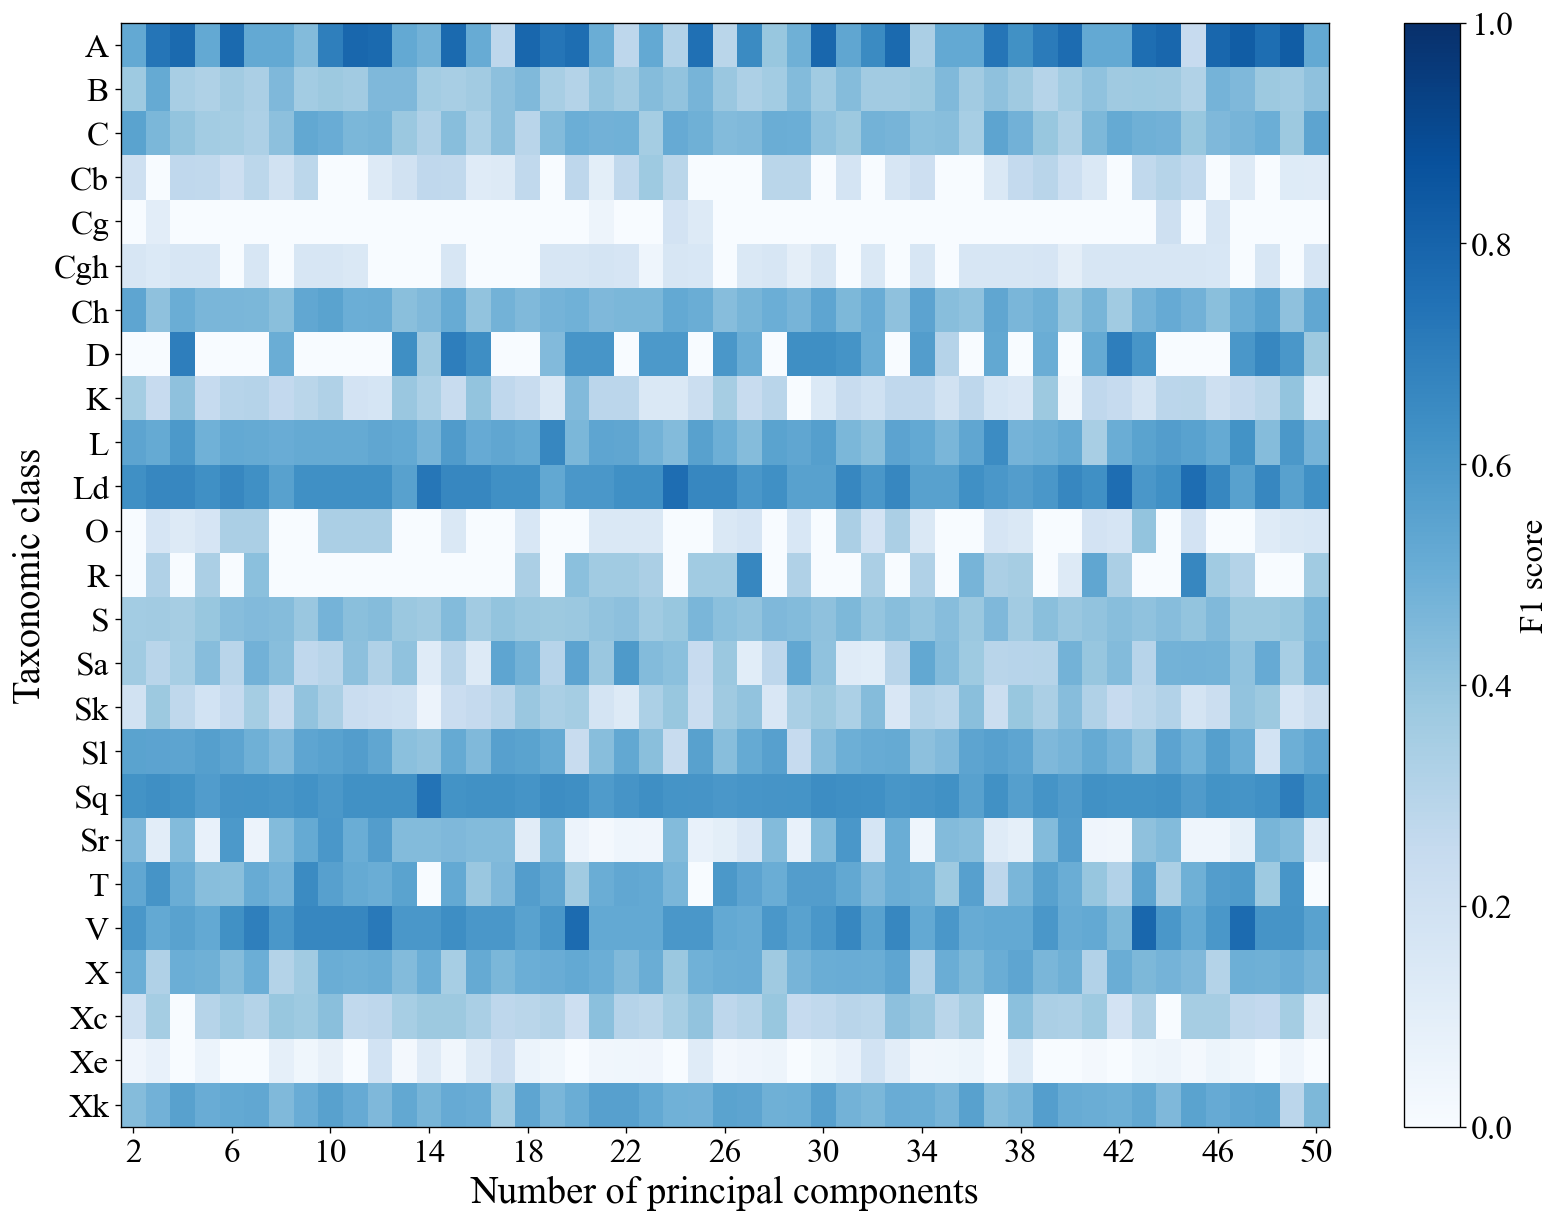

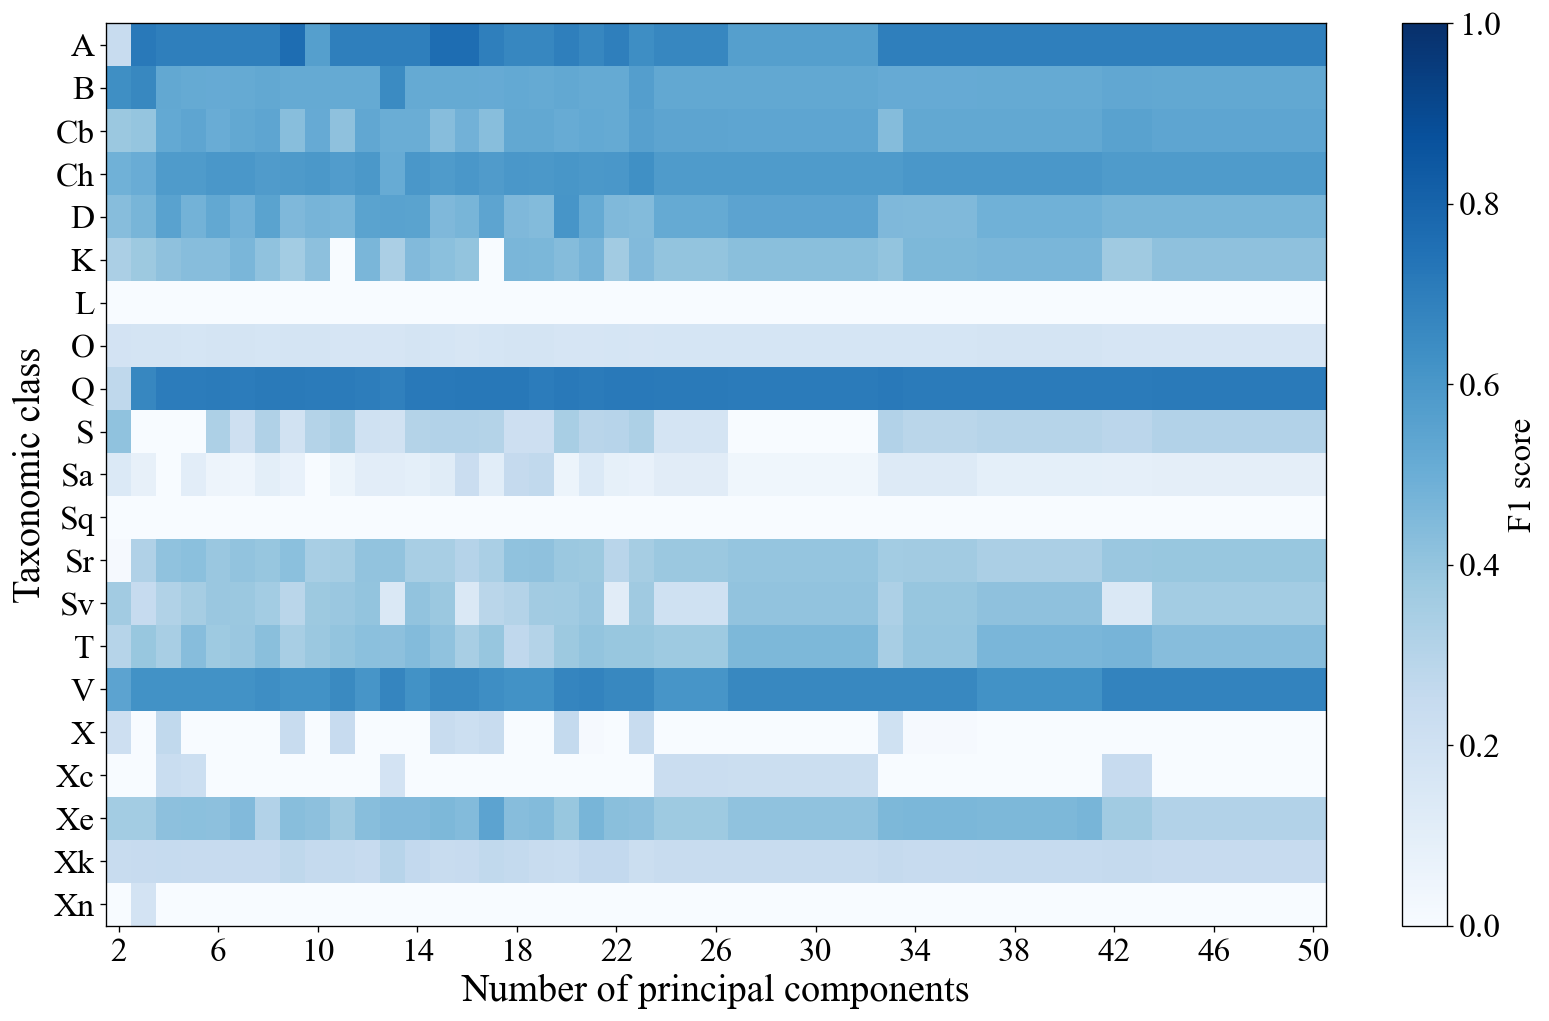

In [79]:
def heatmap(metrics,filename):
    pivot=metrics.pivot(index='class',columns='n_pcs',values='F1')
    fig,ax=plt.subplots(figsize=(14,max(6,len(pivot)*0.42)))
    im=ax.imshow(pivot.values,aspect='auto',vmin=0,vmax=1,cmap='Blues')

    cbar=fig.colorbar(im,ax=ax)
    cbar.set_label('F1 score',fontsize=20)
    cbar.ax.tick_params(labelsize=20)

    step=max(1,len(pivot.columns)//12)
    ticks=np.arange(0,len(pivot.columns),step)
    ax.set_xticks(ticks)
    ax.set_xticklabels(pivot.columns[ticks],fontsize=20)
    ax.set_yticks(np.arange(len(pivot.index)))
    ax.set_yticklabels(pivot.index,fontsize=20)

    ax.set_xlabel('Number of principal components',fontsize=23)
    ax.set_ylabel('Taxonomic class',fontsize=23)
    ax.tick_params(axis='both',labelsize=20)

    fig.tight_layout()
    fig.savefig(VISUALS/f'{filename}.png',bbox_inches='tight',dpi=300)
    fig.savefig(VISUALS/f'{filename}.pdf',bbox_inches='tight')
    plt.show()

heatmap(bus_f1,'04_bus_F1_heatmap')
heatmap(demeo_f1,'05_demeo_F1_heatmap')

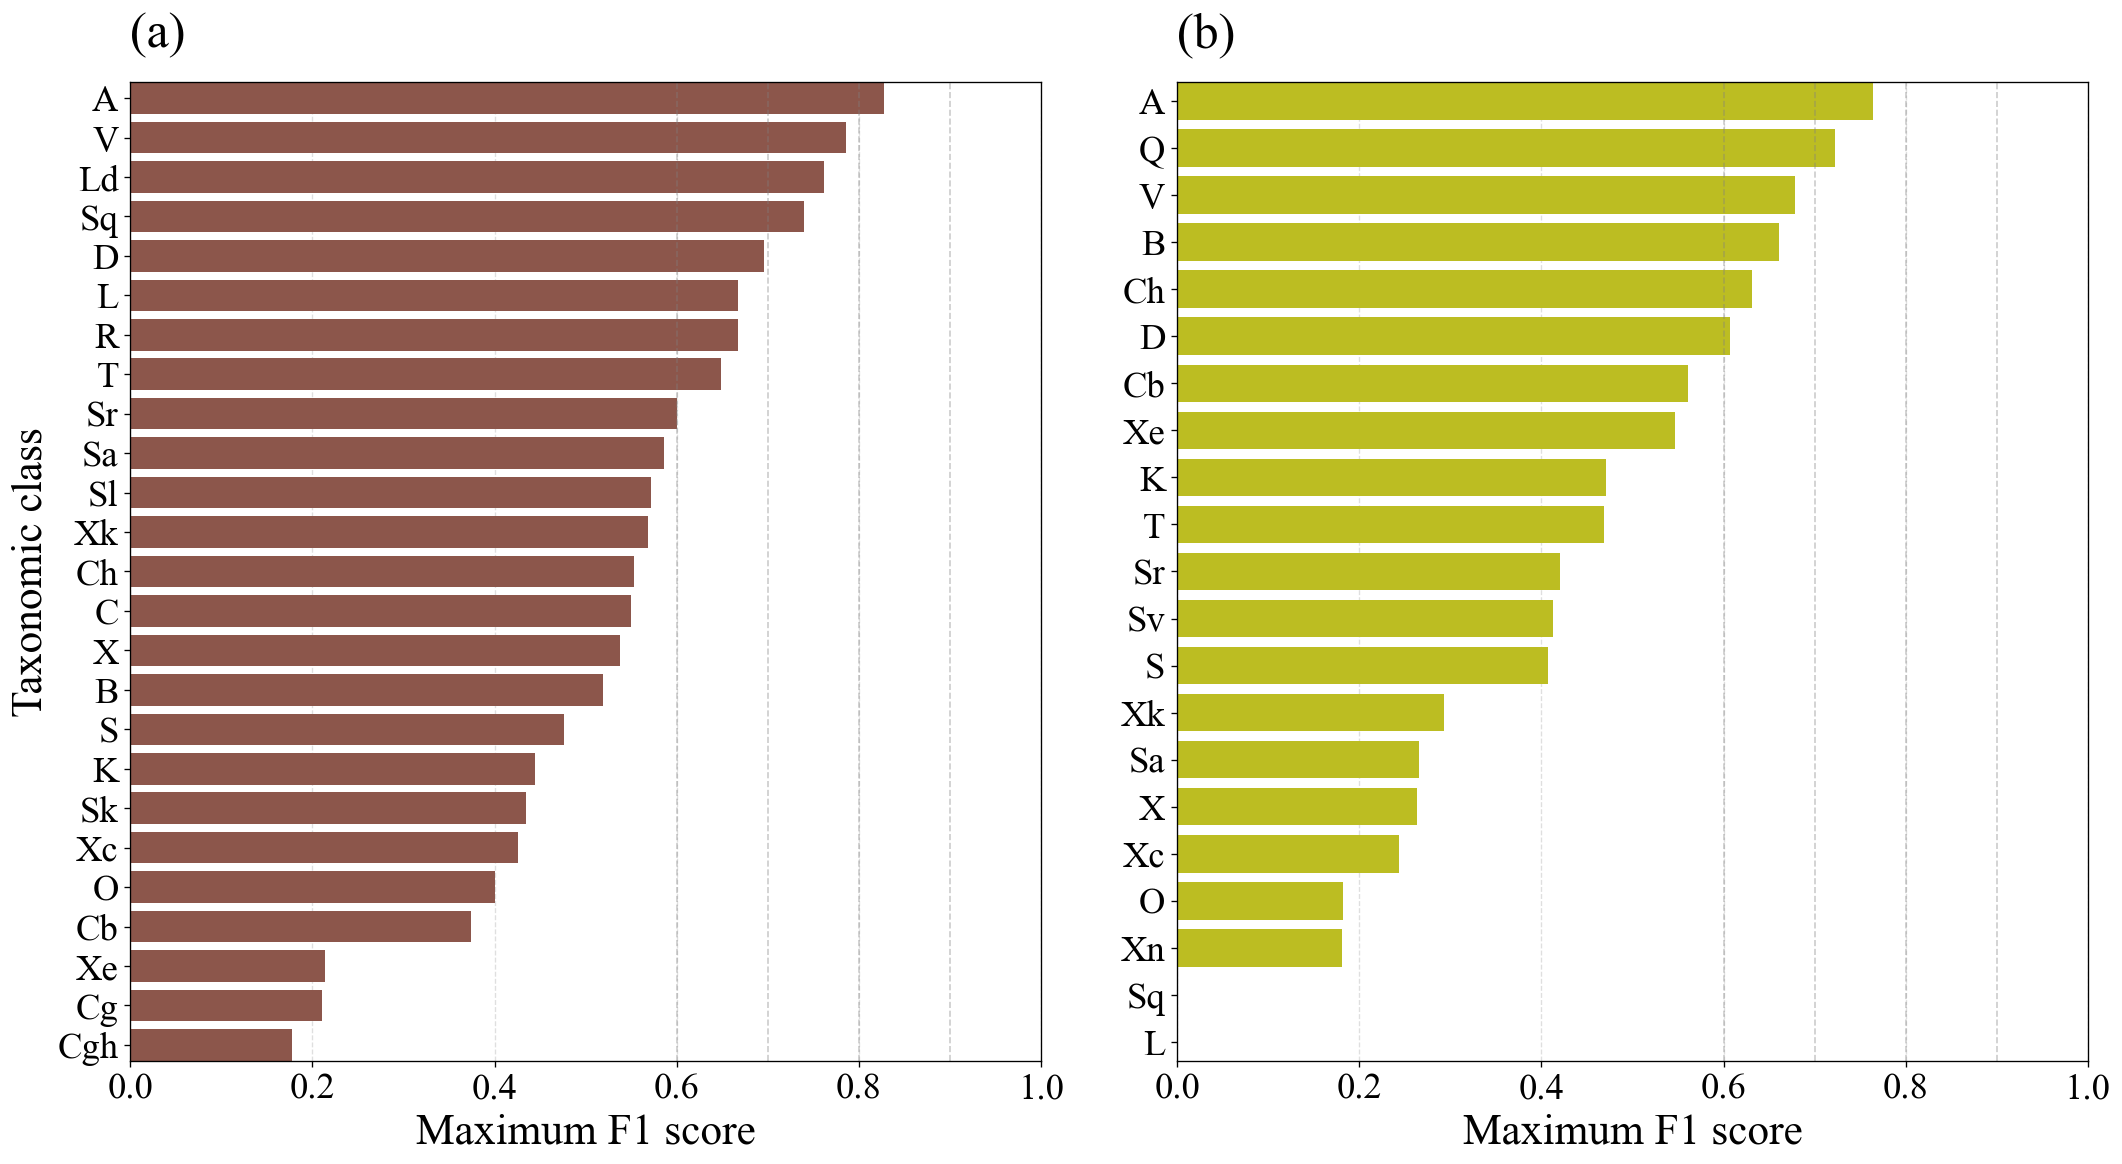

In [87]:
bus_b=bus_best.sort_values('max_F1')
demeo_b=demeo_best.sort_values('max_F1')

fig,axs=plt.subplots(1,2,figsize=(18,10))

axs[0].barh(bus_b['class'],bus_b['max_F1'],color='#8C564B')
axs[1].barh(demeo_b['class'],demeo_b['max_F1'],color='#BCBD22')

for ax in axs:
    for x in [0.60,0.70,0.80,0.90]:
        ax.axvline(x,linestyle='--',linewidth=1,color='gray',alpha=0.4)

    ax.set_xlim(0,1)
    ax.margins(y=0)

    ax.set_xlabel('Maximum F1 score',fontsize=26)
    ax.tick_params(axis='both',labelsize=22)

    ax.grid(axis='x',linestyle='--',linewidth=0.8,alpha=0.25,color='gray')
    ax.set_axisbelow(True)

axs[0].set_ylabel('Taxonomic class',fontsize=26)
axs[1].set_ylabel('')

axs[0].text(0.0,1.025,'(a)',transform=axs[0].transAxes,fontsize=30,va='bottom',ha='left')
axs[1].text(0.0,1.025,'(b)',transform=axs[1].transAxes,fontsize=30,va='bottom',ha='left')

fig.tight_layout(w_pad=2)
fig.savefig(VISUALS/'06_07_max_F1_combined.png',bbox_inches='tight',dpi=300)
fig.savefig(VISUALS/'06_07_max_F1_combined.pdf',bbox_inches='tight')
plt.show()

## 7. Statistical summary of recoverability

In [89]:
band_order=['<0.60','0.60-0.69','0.70-0.79','0.80-0.89','>=0.90']

def recovery_stats(best,ari,dataset):
    x=best['max_F1'].to_numpy()
    return {
        'dataset':dataset,
        'classes':len(best),
        'mean_max_F1':np.mean(x),
        'median_max_F1':np.median(x),
        'std_max_F1':np.std(x,ddof=1),
        'Q1_max_F1':np.quantile(x,0.25),
        'Q3_max_F1':np.quantile(x,0.75),
        'min_max_F1':np.min(x),
        'max_max_F1':np.max(x),
        'classes_F1_ge_0.60':int((x>=0.60).sum()),
        'classes_F1_ge_0.70':int((x>=0.70).sum()),
        'classes_F1_ge_0.80':int((x>=0.80).sum()),
        'classes_F1_ge_0.90':int((x>=0.90).sum()),
        'max_ARI':ari['ARI'].max(),
        'PC_at_max_ARI':int(ari.loc[ari['ARI'].idxmax(),'n_pcs'])
    }

stats_summary=pd.DataFrame([
    recovery_stats(bus_best,bus_ari,'Bus-Binzel VIS'),
    recovery_stats(demeo_best,demeo_ari,'DeMeo VIS-NIR')
])

def band_table(best,name):
    x=best['recovery_band'].value_counts().reindex(band_order,fill_value=0)
    out=x.rename('count').rename_axis('recovery_band').reset_index()
    out['dataset']=name
    out['fraction']=out['count']/out['count'].sum()
    return out

bands=pd.concat([band_table(bus_best,'Bus-Binzel VIS'),band_table(demeo_best,'DeMeo VIS-NIR')],ignore_index=True)

u,p=mannwhitneyu(bus_best['max_F1'],demeo_best['max_F1'],alternative='two-sided')
rb=1-(2*u)/(len(bus_best)*len(demeo_best))
rho_bus,p_bus=spearmanr(bus_best['samples'],bus_best['max_F1'])
rho_demeo,p_demeo=spearmanr(demeo_best['samples'],demeo_best['max_F1'])

inferential=pd.DataFrame([
    {'analysis':'Mann-Whitney U: maximum F1 distributions','statistic':u,'p_value':p,'effect':'rank-biserial','effect_value':rb},
    {'analysis':'Spearman: class size vs maximum F1, Bus-Binzel','statistic':rho_bus,'p_value':p_bus,'effect':'rho','effect_value':rho_bus},
    {'analysis':'Spearman: class size vs maximum F1, DeMeo','statistic':rho_demeo,'p_value':p_demeo,'effect':'rho','effect_value':rho_demeo}
])

stats_summary.to_csv(TABLES/'statistical_summary.csv',index=False)
bands.to_csv(TABLES/'recovery_band_distribution.csv',index=False)
inferential.to_csv(TABLES/'inferential_statistics.csv',index=False)

display(stats_summary)
display(bands)
display(inferential)

,dataset,classes,mean_max_F1,median_max_F1,std_max_F1,Q1_max_F1,Q3_max_F1,min_max_F1,max_max_F1,classes_F1_ge_0.60,classes_F1_ge_0.70,classes_F1_ge_0.80,classes_F1_ge_0.90,max_ARI,PC_at_max_ARI
0,Bus-Binzel VIS,25,0.537324,0.552632,0.175514,0.434783,0.666667,0.177778,0.827586,9,4,1,0,0.279599,10
1,DeMeo VIS-NIR,21,0.418111,0.420792,0.225469,0.263473,0.607287,0.000000,0.763636,6,2,0,0,0.263826,37


,recovery_band,count,dataset,fraction
0,<0.60,16,Bus-Binzel VIS,0.640000
1,0.60-0.69,5,Bus-Binzel VIS,0.200000
2,0.70-0.79,3,Bus-Binzel VIS,0.120000
3,0.80-0.89,1,Bus-Binzel VIS,0.040000
4,>=0.90,0,Bus-Binzel VIS,0.000000
5,<0.60,15,DeMeo VIS-NIR,0.714286
6,0.60-0.69,4,DeMeo VIS-NIR,0.190476
7,0.70-0.79,2,DeMeo VIS-NIR,0.095238
8,0.80-0.89,0,DeMeo VIS-NIR,0.000000
9,>=0.90,0,DeMeo VIS-NIR,0.000000


,analysis,statistic,p_value,effect,effect_value
0,Mann-Whitney U: maximum F1 distributions,340.000000,0.089477,rank-biserial,-0.295238
1,"Spearman: class size vs maximum F1, Bus-Binzel",-0.040054,0.849237,rho,-0.040054
2,"Spearman: class size vs maximum F1, DeMeo",0.416369,0.060450,rho,0.416369


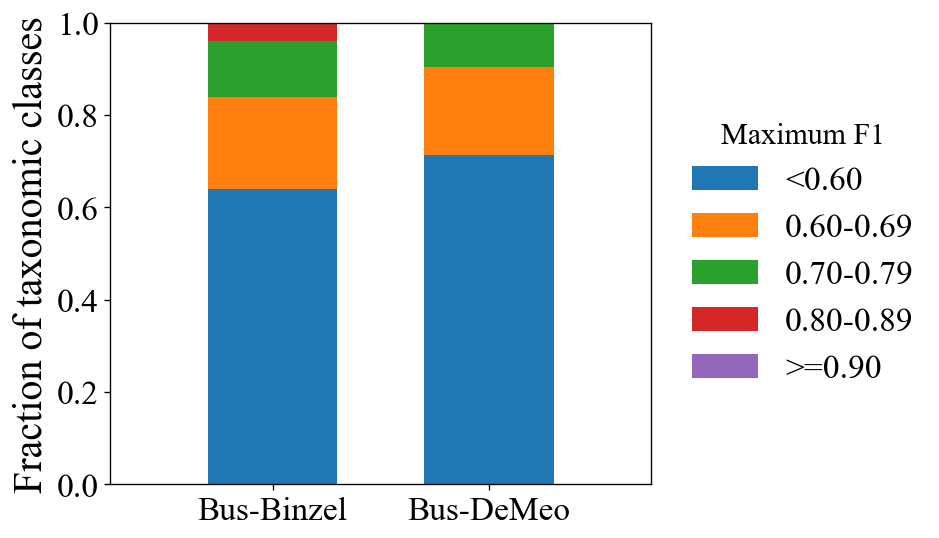

In [151]:
pivot=bands.pivot(index='dataset',columns='recovery_band',values='fraction').reindex(columns=band_order).fillna(0)

fig,ax=plt.subplots(figsize=(10,4.8))
left=np.zeros(len(pivot))

xpos=np.array([0.4,0.6])

for band in band_order:
    vals=pivot[band].to_numpy()
    ax.bar(xpos,vals,bottom=left,width=0.12,label=band)
    left+=vals

ax.set_xlim(0.25,0.75)
ax.set_xticks(xpos)
ax.set_xticklabels(['Bus-Binzel','Bus-DeMeo'],fontsize=24)
ax.set_ylim(0,1)
ax.set_ylabel('Fraction of taxonomic classes',fontsize=24)
ax.set_xlabel('')
ax.tick_params(axis='both',labelsize=20)

ax.legend(
    title='Maximum F1',
    fontsize=20,
    title_fontsize=18,
    frameon=False,
    loc='center left',
    bbox_to_anchor=(1.02,0.5)
)

fig.tight_layout(rect=[0,0,0.82,1])
fig.savefig(VISUALS/'08_recovery_band_distribution.png',bbox_inches='tight',dpi=300)
fig.savefig(VISUALS/'08_recovery_band_distribution.pdf',bbox_inches='tight')
plt.show()

## 8. First PCA dimensionality reaching each recovery threshold

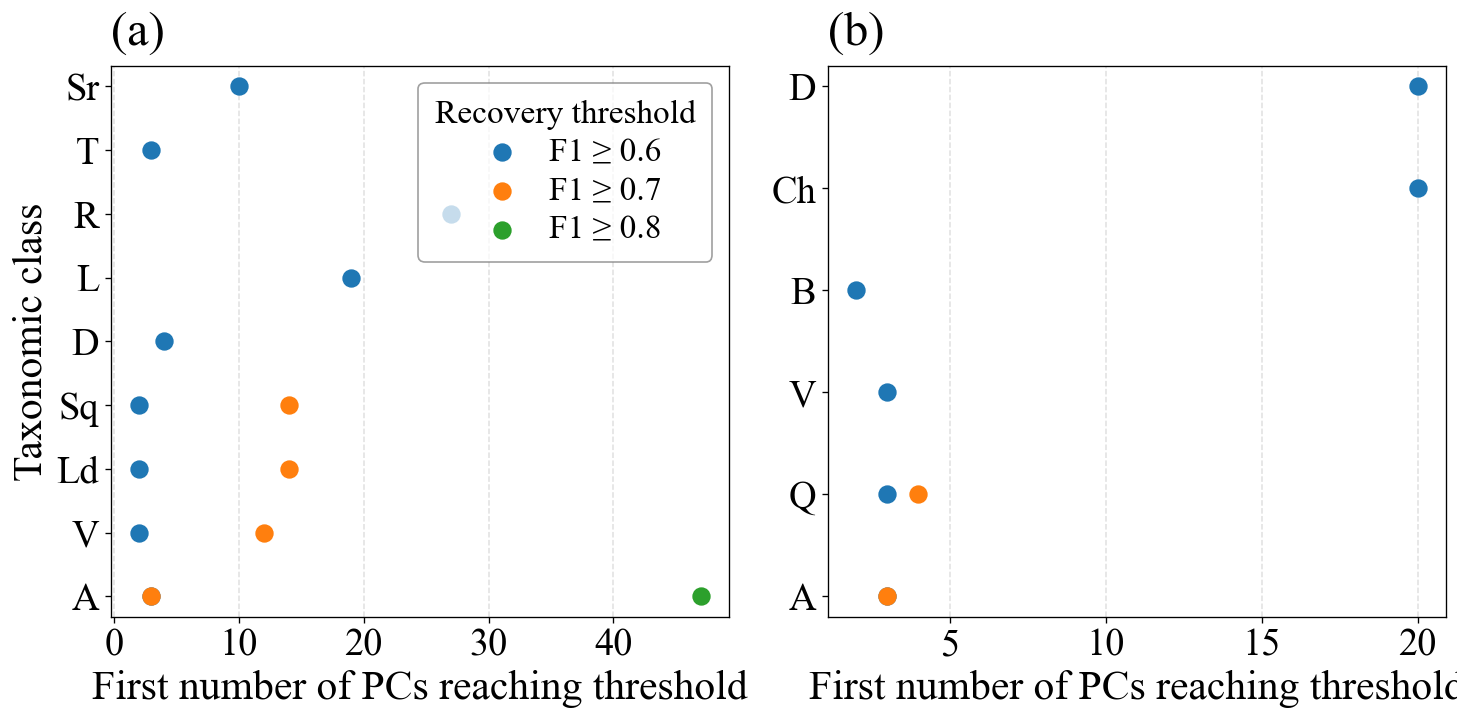

In [190]:
threshold_rows=[]
for _,r in best_all.iterrows():
    for t in THRESHOLDS:
        col=f'first_PC_F1_ge_{str(t).replace(".","_")}'
        threshold_rows.append({'dataset':r['dataset'],'class':r['class'],'threshold':t,'first_PC':r[col]})

threshold_table=pd.DataFrame(threshold_rows)
threshold_table.to_csv(TABLES/'first_PC_by_threshold.csv',index=False)

bus_sub=threshold_table[(threshold_table['dataset']=='Bus-Binzel VIS') & threshold_table['first_PC'].notna()].copy()
demeo_sub=threshold_table[(threshold_table['dataset']=='DeMeo VIS-NIR') & threshold_table['first_PC'].notna()].copy()

fig,axs=plt.subplots(1,2,figsize=(12.5,6.2))

for ax,sub,panel in zip(axs,[bus_sub,demeo_sub],['(a)','(b)']):
    for t,g in sub.groupby('threshold'):
        ax.scatter(g['first_PC'],g['class'],label=f'F1 ≥ {t:.1f}',s=100)

    ax.set_xlabel('First number of PCs reaching threshold',fontsize=25)
    ax.tick_params(axis='both',labelsize=23)
    ax.grid(axis='x',linestyle='--',linewidth=0.9,alpha=0.25,color='gray')
    ax.set_axisbelow(True)
    ax.margins(y=0.04)

    ax.text(
        0.0,1.02,panel,
        transform=ax.transAxes,
        fontsize=29,
        va='bottom',
        ha='left'
    )

axs[0].set_ylabel('Taxonomic class',fontsize=25)
axs[1].set_ylabel('')

axs[0].legend(
    loc='upper right',
    frameon=True,
    framealpha=0.75,
    facecolor='white',
    edgecolor='gray',
    fontsize=20,
    title='Recovery threshold',
    title_fontsize=20,
    labelspacing=0.25,
    handletextpad=0.4,
    borderpad=0.5
)

fig.subplots_adjust(
    left=0.10,
    right=0.99,
    bottom=0.18,
    top=0.92,
    wspace=0.16
)

fig.savefig(VISUALS/'09_10_first_threshold_PC_combined.png',bbox_inches='tight',dpi=300)
fig.savefig(VISUALS/'09_10_first_threshold_PC_combined.pdf',bbox_inches='tight')
plt.show()

## 9. Recovered classes only

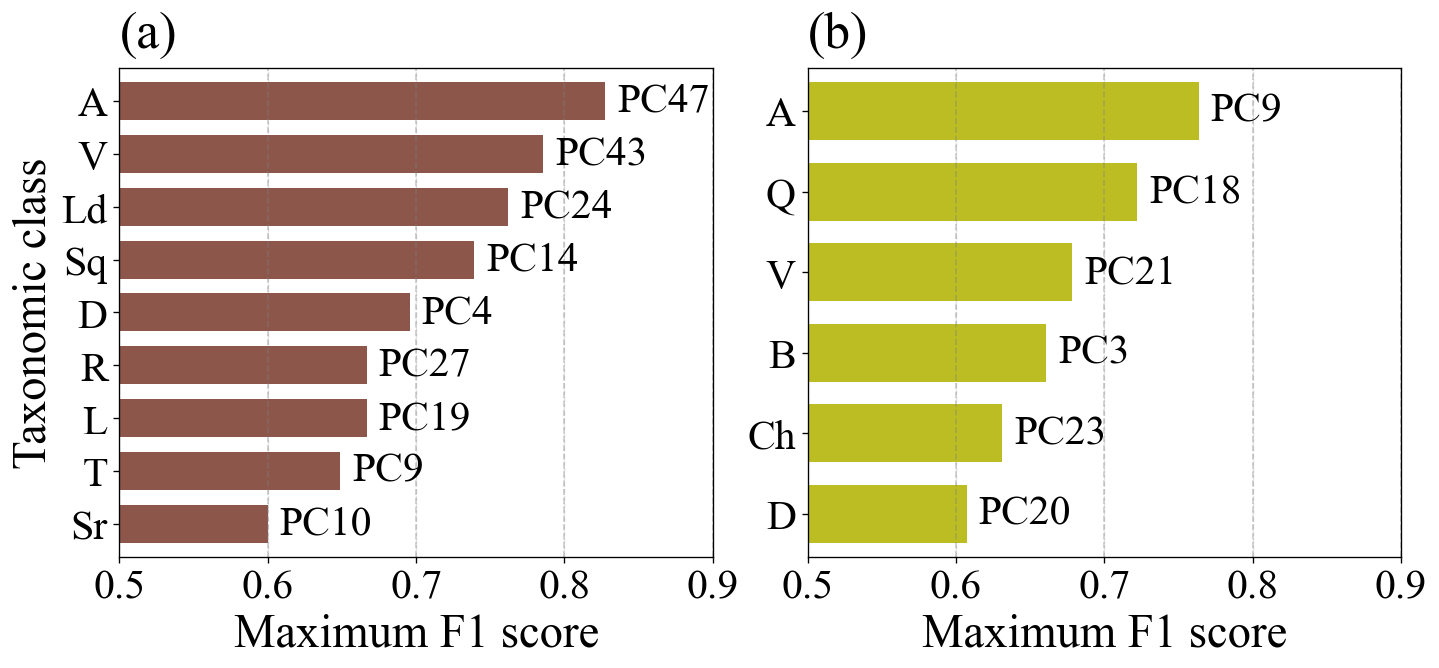

In [188]:
bus_r=bus_best[bus_best['max_F1']>=0.60].sort_values('max_F1')
demeo_r=demeo_best[demeo_best['max_F1']>=0.60].sort_values('max_F1')

fig,axs=plt.subplots(1,2,figsize=(12,5.5))

configs=[
    (axs[0],bus_r,'#8C564B','(a)'),
    (axs[1],demeo_r,'#BCBD22','(b)')
]

for ax,r,color,panel in configs:
    ax.barh(r['class'],r['max_F1'],color=color,height=0.72)

    for i,(_,row) in enumerate(r.iterrows()):
        ax.text(
            row['max_F1']+0.008,
            i,
            f"PC{int(row['best_PC'])}",
            va='center',
            fontsize=25
        )

    for x in [0.60,0.70,0.80,0.90]:
        ax.axvline(x,linestyle='--',linewidth=1,color='gray',alpha=0.4)

    ax.set_xlim(0.5,0.9)
    ax.set_xlabel('Maximum F1 score',fontsize=28)
    ax.tick_params(axis='both',labelsize=25)
    ax.grid(axis='x',linestyle='--',linewidth=0.8,alpha=0.25,color='gray')
    ax.set_axisbelow(True)
    ax.margins(y=0.03)

    ax.text(
        0.0,1.02,panel,
        transform=ax.transAxes,
        fontsize=31,
        va='bottom',
        ha='left'
    )

axs[0].set_ylabel('Taxonomic class',fontsize=28)
axs[1].set_ylabel('')

fig.subplots_adjust(left=0.10,right=0.99,bottom=0.18,top=0.92,wspace=0.16)

fig.savefig(VISUALS/'11_12_recovered_classes_combined.png',bbox_inches='tight',dpi=300)
fig.savefig(VISUALS/'11_12_recovered_classes_combined.pdf',bbox_inches='tight')
plt.show()

## 10. Class size versus recoverability

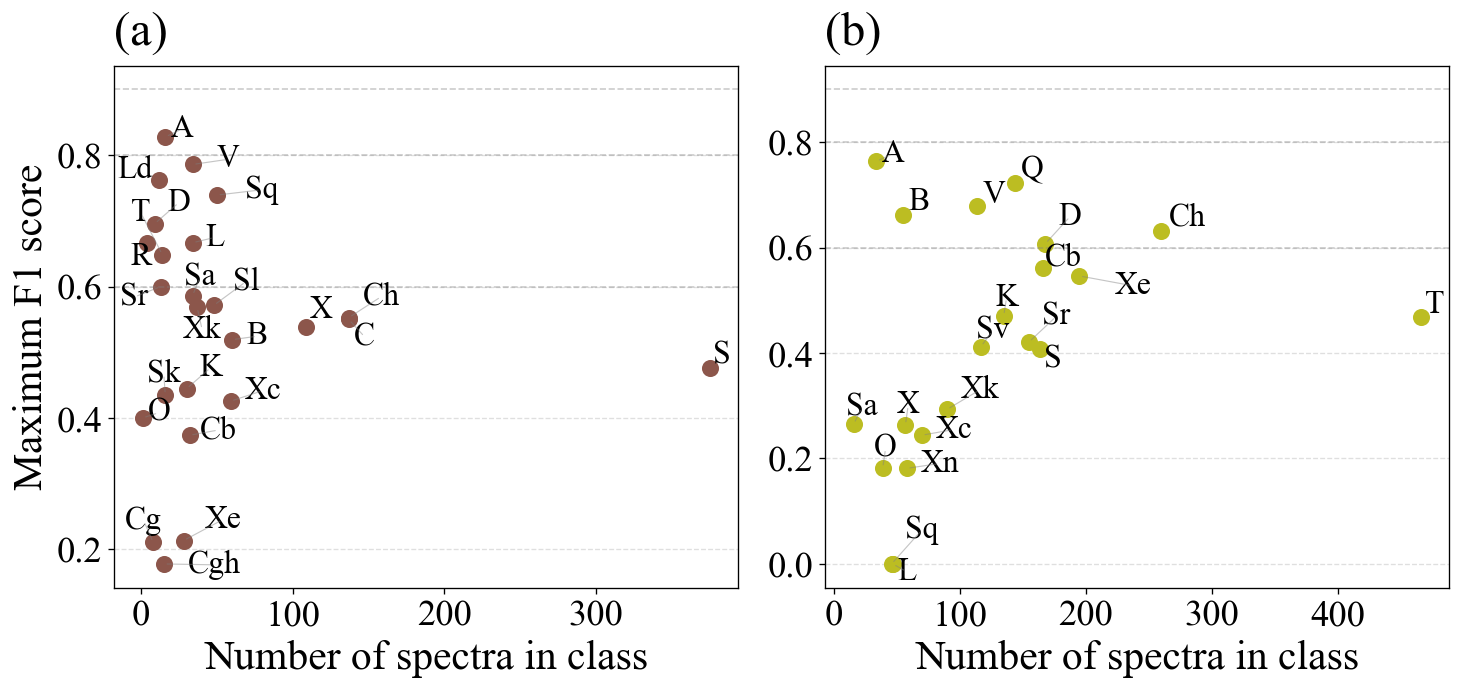

In [192]:
from adjustText import adjust_text

fig,axs=plt.subplots(1,2,figsize=(12.5,5.8))

configs=[
    (axs[0],bus_best,'#8C564B','(a)'),
    (axs[1],demeo_best,'#BCBD22','(b)')
]

for ax,best,color,panel in configs:
    ax.scatter(best['samples'],best['max_F1'],color=color,s=85)

    texts=[]
    for _,r in best.iterrows():
        texts.append(
            ax.text(
                r['samples'],
                r['max_F1'],
                r['class'],
                fontsize=19
            )
        )

    adjust_text(
        texts,
        ax=ax,
        expand=(1.20,1.30),
        force_text=(0.7,0.9),
        force_points=(0.4,0.6),
        arrowprops=dict(
            arrowstyle='-',
            color='gray',
            alpha=0.45,
            linewidth=0.7
        )
    )

    ax.axhline(0.60,linestyle='--',linewidth=1,color='gray',alpha=0.4)
    ax.axhline(0.80,linestyle='--',linewidth=1,color='gray',alpha=0.4)
    ax.axhline(0.90,linestyle='--',linewidth=1,color='gray',alpha=0.4)

    ax.set_xlabel('Number of spectra in class',fontsize=25)
    ax.tick_params(axis='both',labelsize=22)
    ax.grid(axis='y',linestyle='--',linewidth=0.8,alpha=0.25,color='gray')
    ax.set_axisbelow(True)

    ax.text(
        0.0,1.02,panel,
        transform=ax.transAxes,
        fontsize=29,
        va='bottom',
        ha='left'
    )

axs[0].set_ylabel('Maximum F1 score',fontsize=25)
axs[1].set_ylabel('')

fig.subplots_adjust(
    left=0.10,
    right=0.99,
    bottom=0.17,
    top=0.92,
    wspace=0.14
)

fig.savefig(VISUALS/'13_class_size_vs_recovery.png',bbox_inches='tight',dpi=300)
fig.savefig(VISUALS/'13_class_size_vs_recovery.pdf',bbox_inches='tight')
plt.show()

## 11. PCA projections

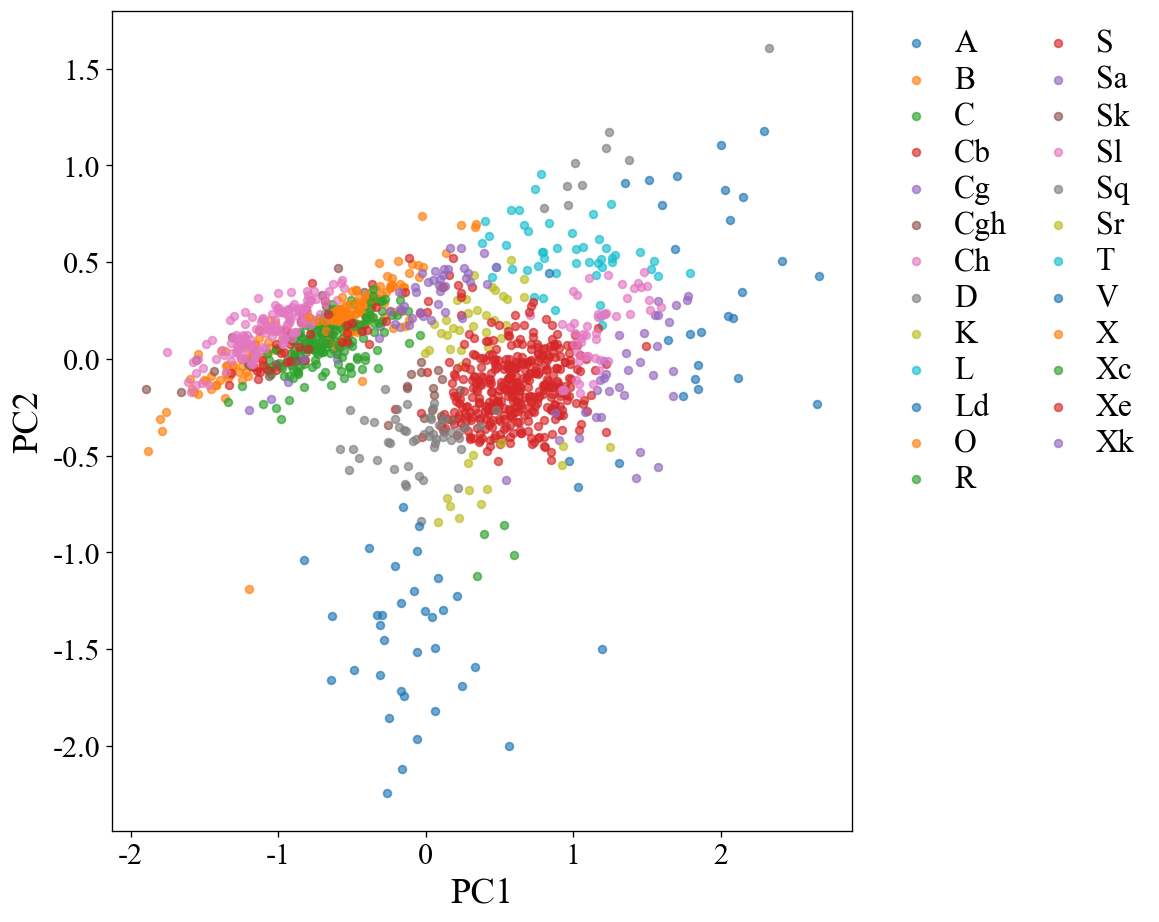

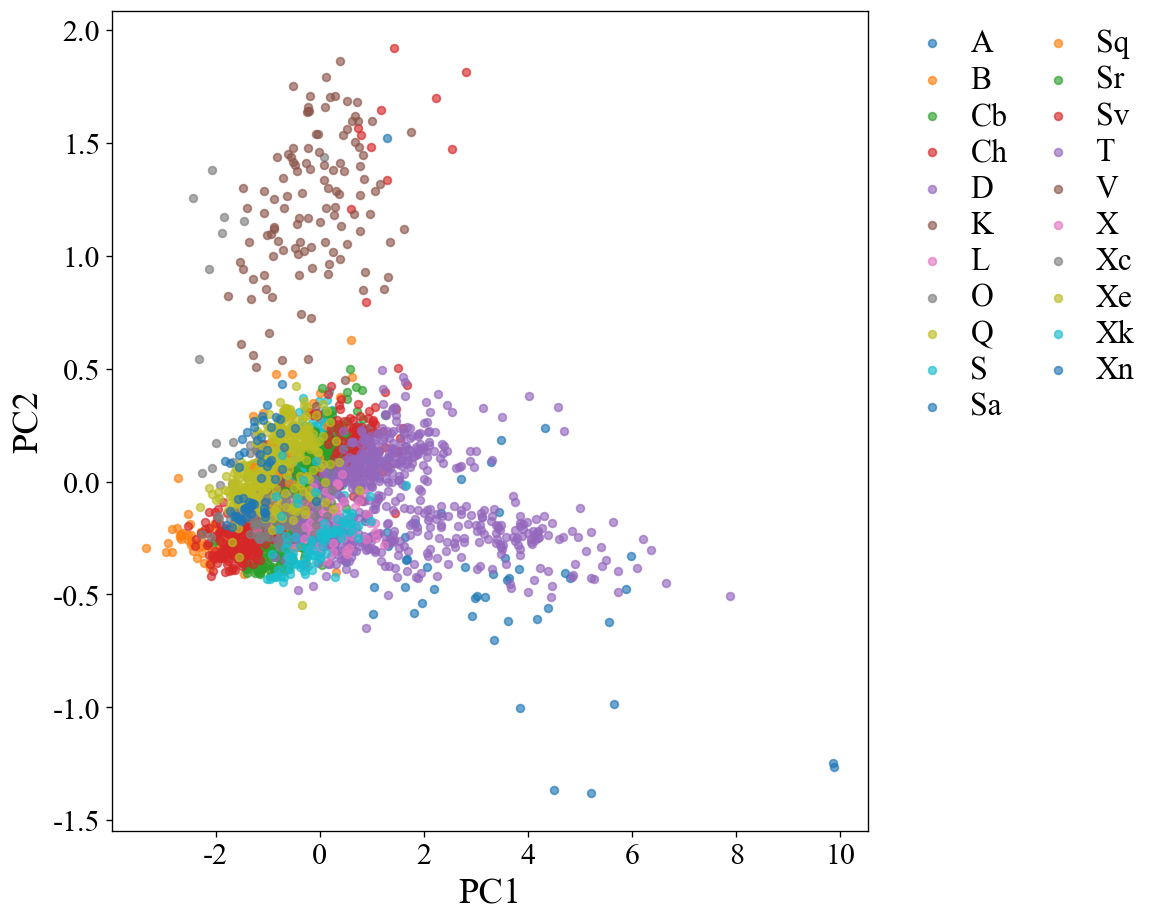

In [131]:
def pca_projection(Z,y,title,filename):
    classes=np.unique(y)
    fig,ax=plt.subplots(figsize=(10,8))
    for cls in classes:
        m=np.asarray(y)==cls
        ax.scatter(Z[m,0],Z[m,1],s=22,alpha=0.65,label=cls)

    ax.set_xlabel('PC1',fontsize=22)
    ax.set_ylabel('PC2',fontsize=22)
    #ax.set_title(title,fontsize=24)
    ax.tick_params(axis='both',labelsize=18)

    ax.legend(
        bbox_to_anchor=(1.02,1),
        loc='upper left',
        ncol=2,
        fontsize=19,
        frameon=False,
        columnspacing=0.6,
        handletextpad=0.2,
        labelspacing=0.2,
        borderaxespad=0.15,
        markerscale=1.0
    )

    fig.tight_layout()
    fig.savefig(VISUALS/f'{filename}.png',bbox_inches='tight',dpi=300)
    fig.savefig(VISUALS/f'{filename}.pdf',bbox_inches='tight')
    plt.show()

pca_projection(Z_bus,y_bus,'Bus-Binzel VIS: PC1 vs PC2','14_bus_PC1_PC2')
pca_projection(Z_demeo,y_demeo,'DeMeo VIS-NIR: PC1 vs PC2','15_demeo_PC1_PC2')

## 12. PCA loadings

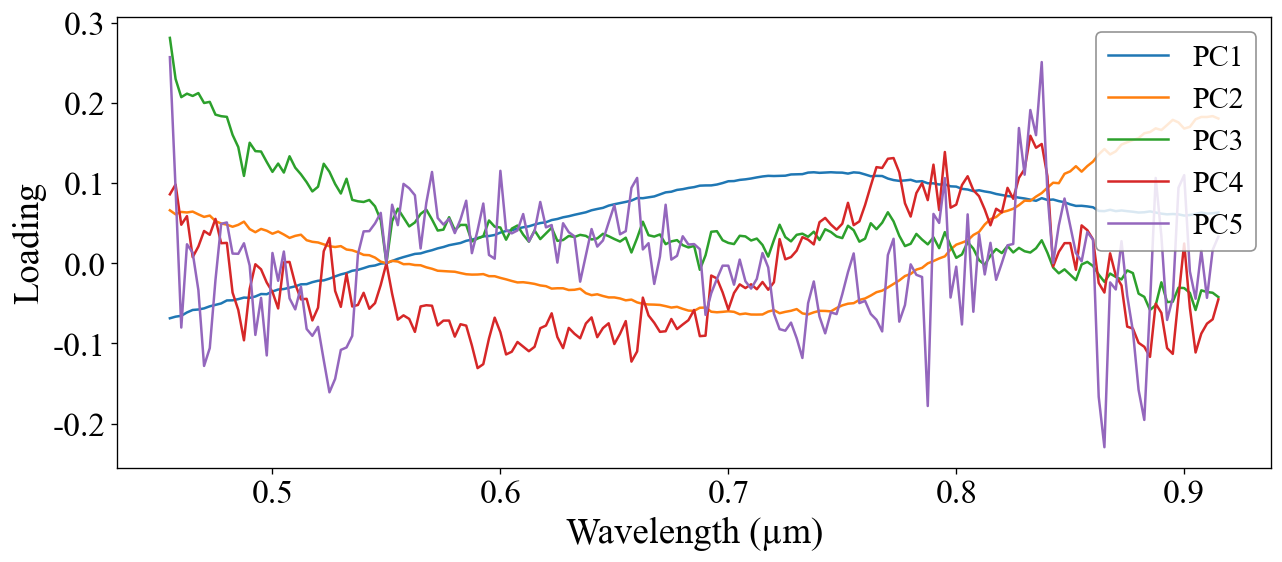

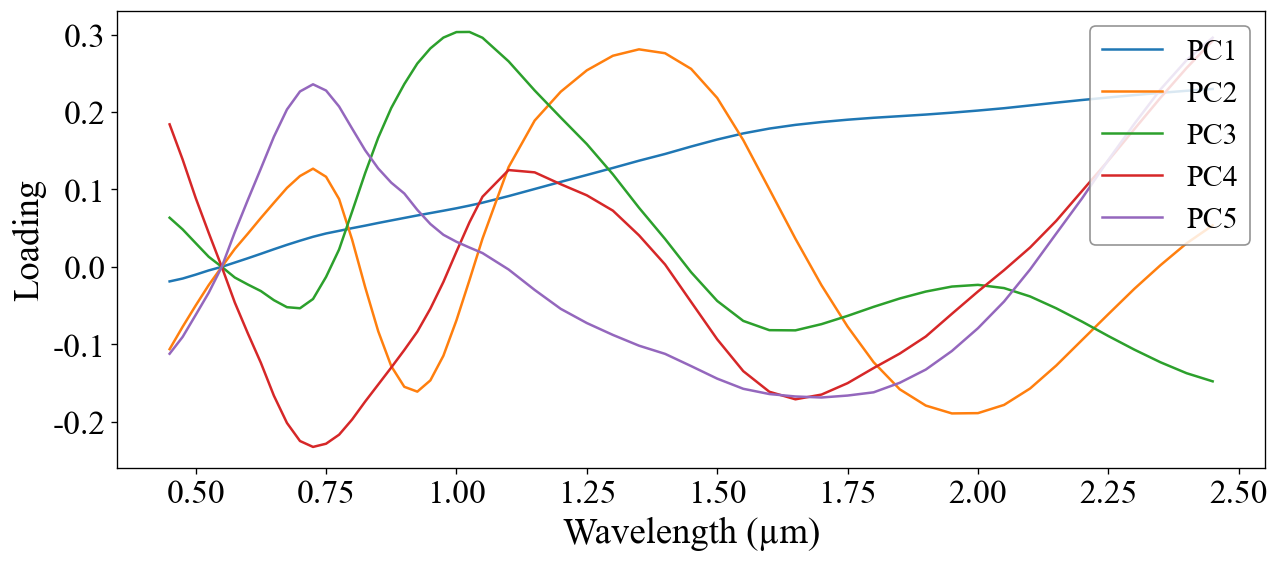

In [137]:
def loading_plot(pca,wavelengths,filename,n=5):
    fig,ax=plt.subplots(figsize=(11,5))
    for i in range(min(n,pca.components_.shape[0])):
        ax.plot(wavelengths,pca.components_[i],label=f'PC{i+1}')
    ax.set_xlabel('Wavelength (µm)',fontsize=22)
    ax.set_ylabel('Loading',fontsize=22)
    ax.tick_params(axis='both',labelsize=20)
    ax.legend(
        loc='upper right',
        fontsize=18,
        frameon=True,
        framealpha=0.84,
        facecolor='white',
        edgecolor='gray'
    )
    fig.tight_layout()
    fig.savefig(VISUALS/f'{filename}.png',bbox_inches='tight',dpi=300)
    fig.savefig(VISUALS/f'{filename}.pdf',bbox_inches='tight')
    plt.show()

loading_plot(pca_bus,[float(c[2:]) for c in bus_final_spec],'16_bus_loadings')
loading_plot(pca_demeo,[float(c) for c in demeo_spec],'17_demeo_loadings')

## 13. Final chapter-ready summary tables

In [42]:
chapter_summary=stats_summary.merge(variance_summary,on='dataset',how='left')
chapter_summary.to_csv(TABLES/'chapter_summary.csv',index=False)

top_classes=pd.concat([
    bus_best.head(10).assign(rank=np.arange(1,min(10,len(bus_best))+1)),
    demeo_best.head(10).assign(rank=np.arange(1,min(10,len(demeo_best))+1))
],ignore_index=True)
top_classes.to_csv(TABLES/'top_recoverable_classes.csv',index=False)

print('All analyses completed.')
print('Visuals:',VISUALS.resolve())
print('Tables:',TABLES.resolve())
display(chapter_summary)
display(top_classes)

All analyses completed.
Visuals: C:\Users\anaoj\Desktop\Citedi\Avances\Capítulo de Libro\PCA_Chapter_Analysis_Results\visuals
Tables: C:\Users\anaoj\Desktop\Citedi\Avances\Capítulo de Libro\PCA_Chapter_Analysis_Results\tables


,dataset,classes,mean_max_F1,median_max_F1,std_max_F1,Q1_max_F1,Q3_max_F1,min_max_F1,max_max_F1,classes_F1_ge_0.60,classes_F1_ge_0.70,classes_F1_ge_0.80,classes_F1_ge_0.90,max_ARI,PC_at_max_ARI,PCs_90,PCs_95,PCs_99
0,Bus-Binzel VIS,25,0.537324,0.552632,0.175514,0.434783,0.666667,0.177778,0.827586,9,4,1,0,0.279599,10,2,5,NaN
1,DeMeo VIS-NIR,21,0.418111,0.420792,0.225469,0.263473,0.607287,0.000000,0.763636,6,2,0,0,0.263826,37,2,3,4.0


,class,best_PC,max_F1,samples,recovery_band,first_PC_F1_ge_0_6,first_PC_F1_ge_0_7,first_PC_F1_ge_0_8,first_PC_F1_ge_0_9,dataset,rank
0,A,47,0.827586,16,0.80-0.89,3.0,3.0,47.0,NaN,Bus-Binzel VIS,1
1,V,43,0.785714,34,0.70-0.79,2.0,12.0,NaN,NaN,Bus-Binzel VIS,2
2,Ld,24,0.761905,12,0.70-0.79,2.0,14.0,NaN,NaN,Bus-Binzel VIS,3
3,Sq,14,0.739130,50,0.70-0.79,2.0,14.0,NaN,NaN,Bus-Binzel VIS,4
4,D,4,0.695652,9,0.60-0.69,4.0,NaN,NaN,NaN,Bus-Binzel VIS,5
5,L,19,0.666667,34,0.60-0.69,19.0,NaN,NaN,NaN,Bus-Binzel VIS,6
6,R,27,0.666667,4,0.60-0.69,27.0,NaN,NaN,NaN,Bus-Binzel VIS,7
7,T,9,0.648649,14,0.60-0.69,3.0,NaN,NaN,NaN,Bus-Binzel VIS,8
8,Sr,10,0.600000,13,0.60-0.69,10.0,NaN,NaN,NaN,Bus-Binzel VIS,9
9,Sa,22,0.586207,34,<0.60,NaN,NaN,NaN,NaN,Bus-Binzel VIS,10


## References and Data Sources

The datasets, taxonomic labels, and methodological context used in this notebook are based on the following sources:

1. **Bus, S. J., & Binzel, R. P. (2002).**  
   *Phase II of the Small Main-Belt Asteroid Spectroscopic Survey: A Feature-Based Taxonomy.*  
   Icarus, 158(1), 146–177.  
   https://doi.org/10.1006/icar.2002.6856

2. **Bus, S. J., & Binzel, R. P. (2002).**  
   *Phase II of the Small Main-Belt Asteroid Spectroscopic Survey: The Observations.*  
   Icarus, 158(1), 106–145.  
   https://doi.org/10.1006/icar.2002.6857

3. **SMASSII – Small Main-Belt Asteroid Spectroscopic Survey, Phase II.**  
   Visible asteroid spectra used in the Bus–Binzel experiment were retrieved from the NASA Planetary Data System (PDS).  
   Dataset: `EAR-A-I0028-4-SBN0001/SMASSII-V1.0`

4. **DeMeo, F. E., Binzel, R. P., Slivan, S. M., & Bus, S. J. (2009).**  
   *An Extension of the Bus Asteroid Taxonomy into the Near-Infrared.*  
   Icarus, 202(1), 160–180.  
   https://doi.org/10.1016/j.icarus.2009.02.005

5. **Mahlke, M., Carry, B., & Mattei, P.-A. (2022).**  
   *Asteroid taxonomy from cluster analysis of spectrometry and albedo.*  
   Astronomy & Astrophysics, 665, A26.  
   https://doi.org/10.1051/0004-6361/202243587  
   Repository: https://github.com/maxmahlke/classy

6. **Ojeda, A. V., Guerrero, C. A., Tapia, J. J., & Sánchez, L. H. (2025).**  
   *Assessing data imputation for asteroid taxonomic classification.*  
   Journal of Astronomical Telescopes, Instruments, and Systems, 11(2), 028006.  
   https://doi.org/10.1117/1.JATIS.11.2.028006  
   Imputed database: https://github.com/AnaOjedaVera/ImputedDatabase

### Data used in this notebook

- **Bus–Binzel VIS experiment:** SMASSII visible spectra retrieved from the NASA PDS and analyzed using the Bus–Binzel taxonomic labels.
- **Bus–DeMeo VIS–NIR experiment:** imputed asteroid spectral database derived from the dataset compiled by Mahlke et al. (2022) and subsequently processed by Ojeda et al. (2025).
- Only spectral reflectance measurements were used for the PCA and clustering experiments; albedo and other metadata were excluded from the PCA representation.